In [78]:
import pandas as pd
import numpy as np

In [79]:
df=pd.read_csv("placement.csv")

In [80]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [82]:
df=df.iloc[:,1:] # all rows, 1 to all columns escape 0

In [83]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0



## Steps

### 0. Preprocess + EDA + Feature Selection
### 1. Extract input and output cols
### 2. Scale the values
### 3. Train test split
### 4. Train the model
### 5. Evaluate the model/model selection
### 6. Deploy the model

In [84]:
import matplotlib.pyplot as plt

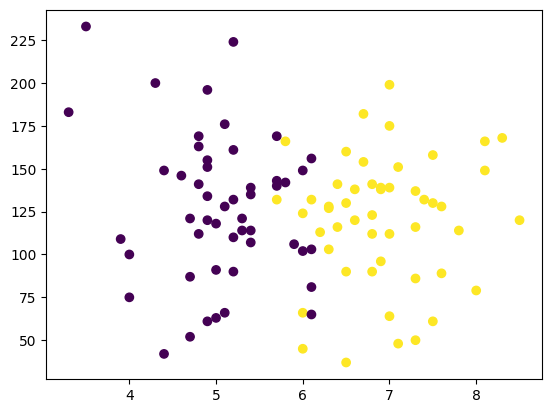

In [85]:
# EDA
plt.scatter(df['cgpa'],df['iq'],c=df['placement']) # yellow show placement is 1

### 1. Extract input and output cols

In [86]:
X=df.iloc[:,0:2] ## Input columns
Y=df.iloc[:,-1] ## Output columns

In [87]:
X


,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [88]:
Y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [89]:
Y.shape

(100,)

### 3. Train test split

In [90]:
from sklearn.model_selection import train_test_split # a library used for it, train_test_split is a function

In [91]:
# train_test_split(X,Y,test_size=0.1) # give both input and output and size means that 10% data will go in test while 90% data will go to the training

In [92]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1)

In [93]:
X_train

,cgpa,iq
1,5.9,106.0
8,6.1,156.0
14,6.1,103.0
30,7.6,128.0
84,5.7,169.0
...,...,...
43,6.8,141.0
66,6.9,96.0
69,8.5,120.0
78,6.1,81.0


In [94]:
X_test

,cgpa,iq
5,7.1,48.0
82,6.5,37.0
10,6.0,45.0
85,5.8,166.0
3,7.4,132.0
38,6.5,160.0
12,5.4,139.0
28,5.2,90.0
25,5.0,91.0
16,5.2,224.0


In [95]:
Y_train

1     0
8     0
14    0
30    1
84    0
     ..
43    1
66    1
69    1
78    0
18    0
Name: placement, Length: 90, dtype: int64

In [96]:
Y_test

5     1
82    1
10    1
85    1
3     1
38    1
12    0
28    0
25    0
16    0
Name: placement, dtype: int64

### 2. Scale the values

In [97]:
from sklearn.preprocessing import StandardScaler

In [98]:
scaler=StandardScaler()

In [99]:
X_train=scaler.fit_transform(X_train)

In [100]:
X_train # all the values will be in between -1 to 1

array([[-0.07599565, -0.50725906],
       [ 0.09499457,  0.84663522],
       [ 0.09499457, -0.58849271],
       [ 1.37742121,  0.08845443],
       [-0.24698587,  1.19864774],
       [-0.84545164, -0.18232443],
       [ 0.26598479, -0.58849271],
       [ 1.80489676,  0.65709003],
       [ 1.2919261 , -1.72576391],
       [-0.75995653,  1.38819294],
       [-1.01644186,  1.19864774],
       [-0.58896631, -0.29063597],
       [ 0.43697501,  0.1426102 ],
       [-1.44391741,  2.03806219],
       [ 0.00949946, -1.59037448],
       [ 0.86445055, -0.34479174],
       [ 1.54841143, -0.29063597],
       [ 0.60796523,  1.55066025],
       [-1.10193697, -0.10109077],
       [ 0.52247012,  0.35923328],
       [ 0.77895545,  0.38631117],
       [-0.5034712 , -0.48018117],
       [-0.93094675,  0.25092174],
       [-0.67446142,  0.98202465],
       [-1.01644186, -0.34479174],
       [-0.75995653,  0.08845443],
       [ 1.12093588, -0.2364802 ],
       [-1.10193697, -1.02173889],
       [-0.5034712 ,

In [101]:
X_test=scaler.fit_transform(X_test)

In [102]:
X_test

array([[ 1.36796137, -1.11794721],
       [ 0.61495511, -1.30655793],
       [-0.0125501 , -1.1693865 ],
       [-0.26355219,  0.90533148],
       [ 1.7444645 ,  0.32235288],
       [ 0.61495511,  0.8024529 ],
       [-0.76555636,  0.44237788],
       [-1.01655845, -0.39779717],
       [-1.26756054, -0.38065074],
       [-1.01655845,  1.8998244 ]])

### 4. Train the model

In [103]:
from sklearn.linear_model import LogisticRegression

In [104]:
clf=LogisticRegression()

In [138]:
clf.fit(X_train,Y_train)

LogisticRegression()

### 5. Evaluate the model/model selection

In [139]:
Y_pred=clf.predict(X_test)

In [140]:
Y_pred

array([1, 1, 0, 0, 1, 1, 0, 0, 0, 0])

In [141]:
Y_test

5     1
82    1
10    1
85    1
3     1
38    1
12    0
28    0
25    0
16    0
Name: placement, dtype: int64

In [132]:
from sklearn.metrics import accuracy_score # used for accuracy or probability 

In [142]:
accuracy_score(Y_test,Y_pred)

0.8

In [ ]:
# How to plot the decision boundary 
# means which pattern ML used for this data.
# to visualize it we use the library MLxtend     
# import sys
# !{sys.executable} -m pip install mlxtend

In [131]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

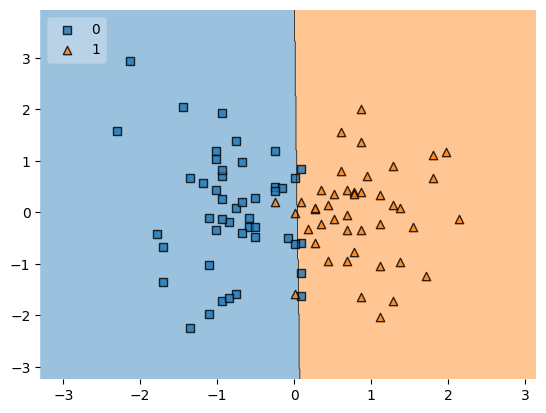

In [ ]:
plot_decision_regions(X_train, Y_train.values,clf=clf, legend=2) # .values to convert to numpy array

In [ ]:
import pickle # convert object into file and then we can use that file in any other envirnment

In [129]:
pickle.dump(clf,open('ML1stModel.pk1','wb'))